In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
data=pd.read_csv('Zomato-data-.csv')

In [6]:
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [8]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)
    

In [9]:
data['rate']=data['rate'].apply(handleRate)

In [10]:
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [12]:
data.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

# Popullar resturant catogory

Text(0.5, 0, 'Type of resturant')

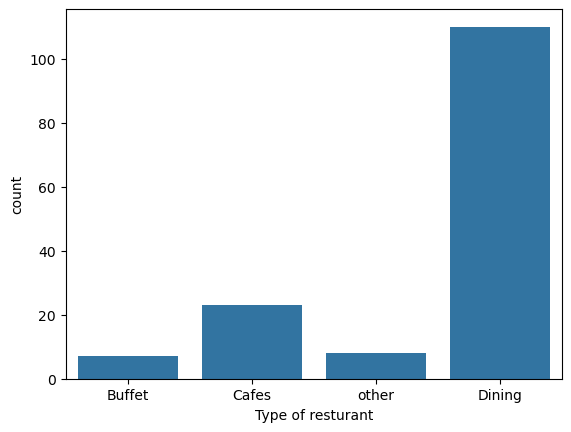

In [13]:
sns.countplot(x=data['listed_in(type)'])
plt.xlabel("Type of resturant")

In [14]:
# majority of the resturants fall into the dining category 

# Voted by Resturant Type

In [15]:
grouped_data=data.groupby('listed_in(type)')['votes'].sum()

In [16]:
result=pd.DataFrame({'votes':grouped_data})

Text(0, 0.5, 'Votes')

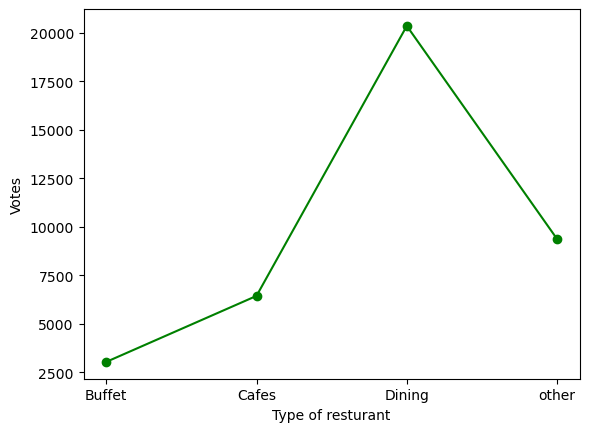

In [17]:
plt.plot(result,c='green',marker='o')
plt.xlabel('Type of resturant')
plt.ylabel('Votes')

Dining resturants are prefered by a larger number of individuals

# maximum vote resturant

In [18]:
max_votes=data['votes'].max()
resturant_with_max_votes=data.loc[data['votes']==data['votes'].max(),'name']

In [19]:
print('Resturant with the maximum votes:')
resturant_with_max_votes

Resturant with the maximum votes:


38    Empire Restaurant
Name: name, dtype: object

# Online order availability


<Axes: xlabel='online_order', ylabel='count'>

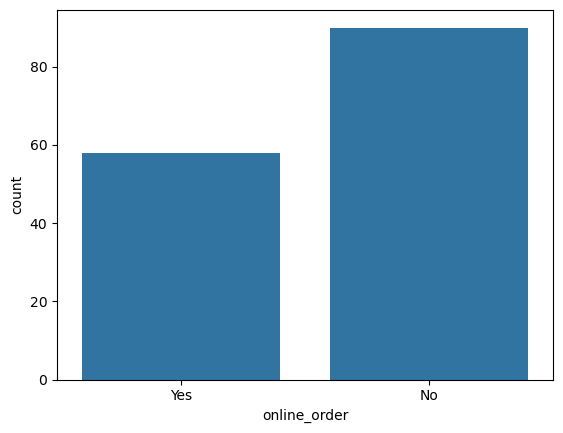

In [20]:
sns.countplot(x=data['online_order'])

 this shows that a majority  of the resturants do not accept online orders

# Rating Distribution

In [21]:
data['rate'].min()

2.6

In [22]:
data['rate'].max()

4.6

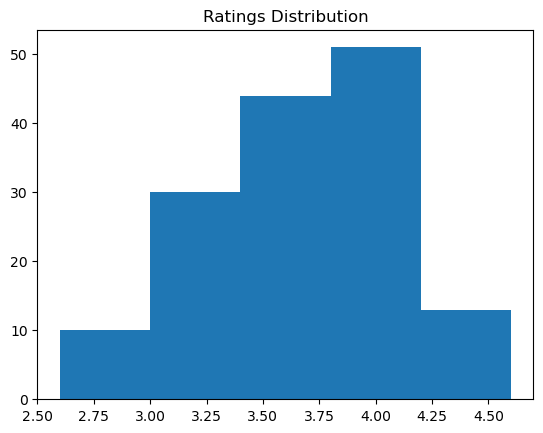

In [23]:
plt.hist(data['rate'],bins=5)
plt.title("Ratings Distribution")
plt.show()

In [24]:
#majority of resturants received ratings ranging from 3.5 to 4.0

# Approximate Cost for Couples

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

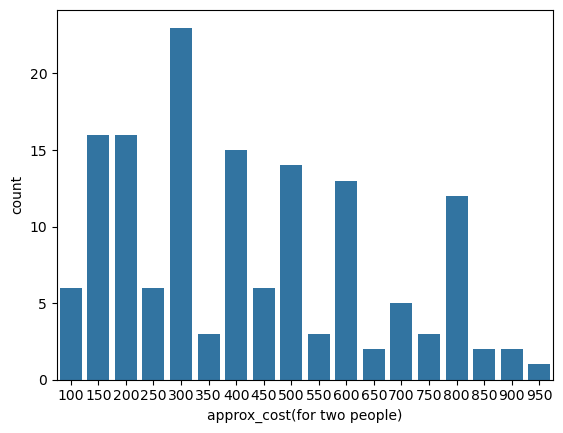

In [25]:
couple_data=data['approx_cost(for two people)']
sns.countplot(x=couple_data)

 The majority of couples prefer resturants with an approximate cost of 300 rupees

# Ratings Comprison -Online vs Offline Orders

<Axes: xlabel='online_order', ylabel='rate'>

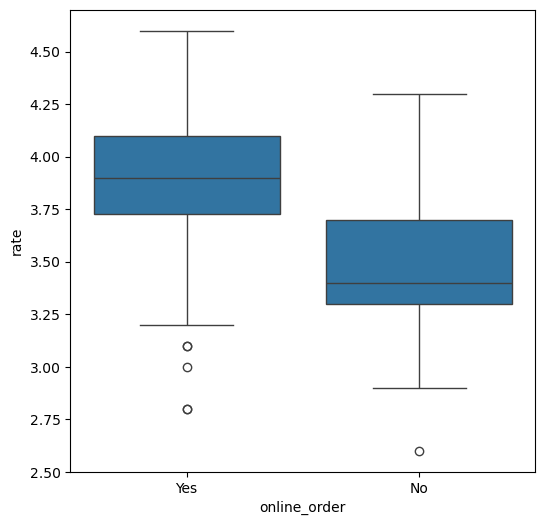

In [26]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=data)

 offline orders received lower ratings in comprison to onlne orders which obtained excellent ratings

In [27]:
pivot_table=data.pivot_table(
    index='listed_in(type)',
    columns='online_order',
    aggfunc='size',
    fill_value=0
)

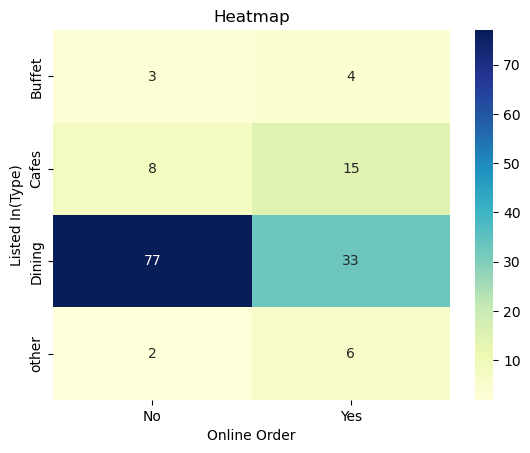

In [28]:
sns.heatmap(pivot_table,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In(Type)')
plt.show()

 we can say that dinning resturants primarily accept offline orders whereas cafes primarilly receive online orders.This suggests that clients  prefer to place orders in person at resturants but prefer online ordering at Cafes 

# Zomato Data Analysis Report
## Exploratory Data Analysis on Restaurant Dataset

## Dataset Introduction

This project analyzes the Zomato restaurant dataset to understand customer preferences, restaurant ratings, online ordering trends, and restaurant costs. The dataset contains information about restaurant types, votes, ratings, online ordering facilities, and approximate costs for two people.

## Data Cleaning Summary

- Missing values were checked and handled.
- The rating column was converted into numerical format.


These preprocessing steps improved the quality of the dataset for analysis.

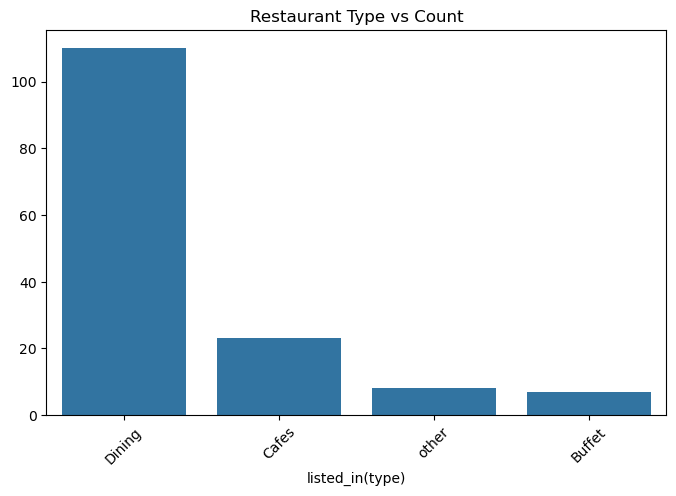

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x=data["listed_in(type)"].value_counts().index,
            y=data["listed_in(type)"].value_counts().values)

plt.title("Restaurant Type vs Count")
plt.xticks(rotation=45)
plt.show()

## Visualization 1: Restaurant Type Distribution

The chart shows that dining restaurants are the most common category in the dataset. This indicates that customers highly prefer dine-in experiences.

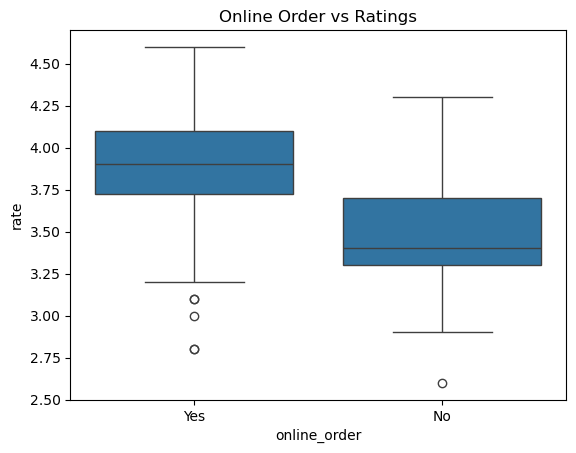

In [39]:
sns.boxplot(x="online_order", y="rate", data=data)

plt.title("Online Order vs Ratings")
plt.show()

## Visualization 2: Online Orders vs Ratings

Restaurants offering online ordering services generally receive better ratings. This suggests that customer convenience positively affects restaurant popularity.

## Key Insights

1. Dining restaurants are the most popular restaurant type.

2. Restaurants with online ordering tend to have higher ratings.

3. Customers mostly prefer affordable restaurants with moderate pricing.

## Conclusion

The analysis shows that restaurant success depends on customer convenience, pricing, and dining experience. Restaurants with online ordering and affordable pricing receive better customer engagement and ratings.